In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_PATH = "../data/classification/train"
VAL_PATH = "../data/classification/val"

train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1750 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [3]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [4]:
for layer in base_model.layers:
    layer.trainable = False

In [5]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.1909 - loss: 2.9385 - val_accuracy: 0.3947 - val_loss: 2.4479
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.4851 - loss: 1.9777 - val_accuracy: 0.5333 - val_loss: 1.9340
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.6211 - loss: 1.4455 - val_accuracy: 0.5867 - val_loss: 1.6193
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.7371 - loss: 1.0909 - val_accuracy: 0.6613 - val_loss: 1.3906
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.8017 - loss: 0.8527 - val_accuracy: 0.6693 - val_loss: 1.3049
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.8423 - loss: 0.6905 - val_accuracy: 0.6640 - val_loss: 1.2307
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - accuracy: 0.8657 - loss: 0.5855 - val_accuracy: 0.6827 - val_loss: 1.2089
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.8994 - loss: 0.4976 - val_accuracy: 0.6960 - v

In [8]:
model.save("../models/vgg16_model.h5")
print("Model Saved ✅")

Model Saved ✅


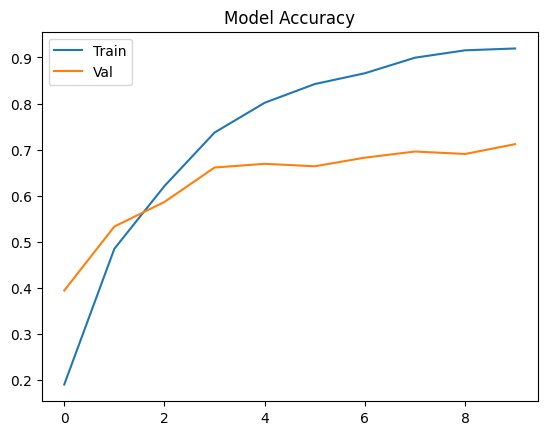

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Val"])
plt.show()